# Objective

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [2]:
df = pd.read_csv("../data/processed/cleaned_retail_data.csv")

In [3]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [4]:
df = pd.read_csv(
    "../data/processed/cleaned_retail_data.csv"
)

# Dataset Overview

In [5]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalSales,Year,Month,Day,Hour,DayOfWeek,DayName,IsWeekend,Season,InventoryLevel,CustomerTotalSales,HolidaySeason
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,1,7,1,Tuesday,0,Winter,112,2017.2,1
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1,7,1,Tuesday,0,Winter,445,2017.2,1
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1,7,1,Tuesday,0,Winter,358,2017.2,1
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,12,1,7,1,Tuesday,0,Winter,280,2017.2,1
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,12,1,7,1,Tuesday,0,Winter,116,2017.2,1


how much each product sells

# Inventory Analysis

In [6]:
inventory_df = df.groupby(
    "Description"
).agg({

    "Quantity": "sum",

    "TotalSales": "sum"

}).reset_index()

In [7]:
inventory_df.columns = [

    "Product",

    "TotalQuantitySold",

    "TotalRevenue"
]

In [8]:
np.random.seed(42)

inventory_df["CurrentStock"] = np.random.randint(

    20,
    500,

    size=len(inventory_df)
)

# Inventory Optimization

In [9]:
inventory_df["ReorderLevel"] = 50

In [10]:
inventory_df["LowStockAlert"] = np.where(

    inventory_df["CurrentStock"]
    < inventory_df["ReorderLevel"],

    "YES",

    "NO"
)

In [11]:
inventory_df.head()

,Product,TotalQuantitySold,TotalRevenue,CurrentStock,ReorderLevel,LowStockAlert
0,DOORMAT UNION JACK GUNS AND ROSES,167,1071.25,122,50,NO
1,3 STRIPEY MICE FELTCRAFT,662,1241.10,455,50,NO
2,4 PURPLE FLOCK DINNER CANDLES,200,265.20,368,50,NO
3,ANIMAL STICKERS,385,80.85,290,50,NO
4,BLACK PIRATE TREASURE CHEST,45,74.25,126,50,NO


In [12]:
low_stock = inventory_df[
    inventory_df["LowStockAlert"] == "YES"
]

low_stock.head()

,Product,TotalQuantitySold,TotalRevenue,CurrentStock,ReorderLevel,LowStockAlert
7,CAMPHOR WOOD PORTOBELLO MUSHROOM,43,53.75,40,50,YES
33,12 EGG HOUSE PAINTED WOOD,364,3751.40,41,50,YES
57,200 BENDY SKULL STRAWS,601,682.85,40,50,YES
64,3 HOOK HANGER MAGIC GARDEN,1056,1854.00,33,50,YES
85,36 PENCILS TUBE RED SPOTTY,3225,3882.29,21,50,YES


In [13]:
top_products = inventory_df.sort_values(

    by="TotalRevenue",
    ascending=False

).head(10)

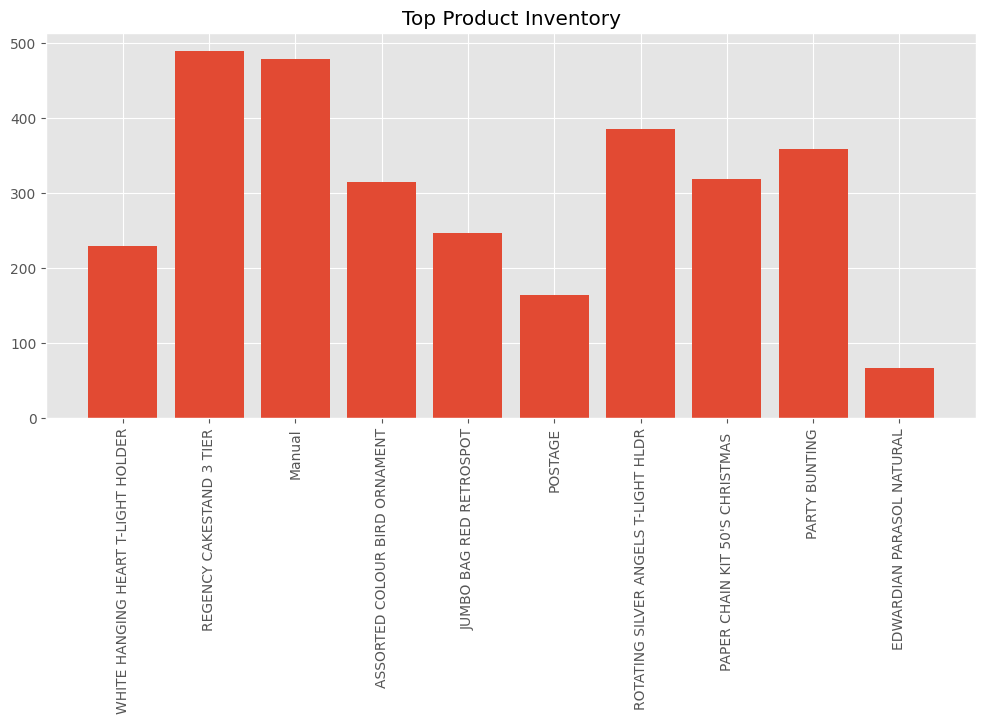

In [14]:
plt.figure(figsize=(12,5))

plt.bar(

    top_products["Product"],
    top_products["CurrentStock"]

)

plt.xticks(rotation=90)

plt.title("Top Product Inventory")

plt.show()

# Conclusion

In [15]:
inventory_df.to_csv(

    "../data/processed/inventory_data.csv",

    index=False
)

In [16]:
print(inventory_df.columns)

Index(['Product', 'TotalQuantitySold', 'TotalRevenue', 'CurrentStock',
       'ReorderLevel', 'LowStockAlert'],
      dtype='str')
